# Report on Customer Segmentation

![doctor-on-the-office-1024x683](doctor-on-the-office-1024x683.jpg)

## The following report is divided into 6 stages:
* __Background__ - Gives context to this report
* __The Data__ - The data available for analysis
    *  Doctors contains information on doctors. Each row represents one doctor.
    *  Orders contains details on orders. Each row represents one order; a doctor can place multiple orders.
    *  Complaints collects information on doctor complaints.
    *  Instructions has information on whether the doctor includes special instructions on their orders.
* __Methodology__ - Explains methods used to achieve results
* __What the managers wants to know?__ - Answering specific questions through statistic analysis and Machine Learning
    * How many doctors are there in each region? What is the average number of purchases per region?
    * Can you find a relationship between purchases and complaints?
    * Define new doctor segments that help the company improve marketing efforts and customer service.
    * Identify which features impact the new segmentation strategy the most.
    * Your team will need to explain the new segments to the rest of the company. Describe which characteristics distinguish the newly defined segments.
* __Recommendations__ - My interpretation of the personas, with insights to the marketing team
* __Appendix__ - Overall code used in the tasks
    * Code for questions of analysis
    * Code of ML pipeline for repeatability

# Can you find a better way to segment your customers?

## 📖 Background
I work as a Data Scientist in a medical device manufacturer in Switzerland called Johansson & Johansson, a company that manufactures orthopedic devices and sells them worldwide, directly to individual doctors who use them on rehabilitation and physical therapy patients.

Historically, the sales and customer support departments have grouped doctors by geography. However, the region is not a good predictor of the number of purchases a doctor will make or their support needs.

My team wants to use a data-centric approach to segmenting doctors to improve marketing, customer service, and product planning. 

## 💾 The Data

The company stores the information you need in the following four tables. Some of the fields are anonymized to comply with privacy regulations.

#### Doctors contains information on doctors. Each row represents one doctor.
- "DoctorID" - is a unique identifier for each doctor.
- "Region" - the current geographical region of the doctor.
- "Category" - the type of doctor, either 'Specialist' or 'General Practitioner.'
- "Rank" - is an internal ranking system. It is an ordered variable: The highest level is Ambassadors, followed by Titanium Plus, Titanium, Platinum Plus, Platinum, Gold Plus, Gold, Silver Plus, and the lowest level is Silver.
- "Incidence rate"  and "R rate" - relate to the amount of re-work each doctor generates.
- "Satisfaction" - measures doctors' satisfaction with the company.
- "Experience" - relates to the doctor's experience with the company.
- "Purchases" - purchases over the last year.

#### Orders contains details on orders. Each row represents one order; a doctor can place multiple orders.
- "DoctorID" - doctor id (matches the other tables).
- "OrderID" - order identifier.
- "OrderNum" - order number.
- "Conditions A through J" - map the different settings of the devices in each order. Each order goes to an individual patient.

#### Complaints collects information on doctor complaints.
- "DoctorID" - doctor id (matches the other tables).
- "Complaint Type" - the company's classification of the complaints.
- "Qty" - number of complaints per complaint type per doctor.

#### Instructions has information on whether the doctor includes special instructions on their orders.
- "DoctorID" - doctor id (matches the other tables).
- "Instructions" - 'Yes' when the doctor includes special instructions, 'No' when they do not.

## ⚙️ Methodology

In order to reach to a conclusion on how customers are segmented on our data, an approach using unsupervised machine learning was used, as it is easy to interpretate and not computationally heavy.

For the algorithm to be able to process the data correctly:
1. After cleaning the data, a set of ordinal and continuous variables were selected to be processed
2. The ordinal variable was label-encoded so it could represent a numerical rank and consequentially, enabling it to be processed
3. Since the K-means algorithm is sensible to distances (huge numerical sizes), the selected variables needed to be normalized
4. As a tentative to reduce the dimentionality (number of variables) of the data, since the selected variables were already normalized, a Principal Component Analysis could be performed
5. After observing that 5 out of 7 Principal Components explain more than 80% of the data, those 2 Principal Components were discarded
6. The re-dimensioned data was then fed to the K-means, with a choosed "k" of 4 clusters
7. The resulting labels were then added to the data, where the features of analysis were grouped by each label and displaying the mean value to assist the interpretability of the clusters, thus creating the segments


## 📖 What the managers want to know?

### 👉 How many doctors are there in each region? What is the average number of purchases per region?

Sometimes due to demographic factors, the distribution of doctors are not the same throughout a given area. Even so, we find a some regions with particularly high averages and other with less, as per below

![Number of Doctors and Average Purchases per Region](Number%20of%20Doctors%20and%20Average%20Purchases%20per%20Region.png)


### 👉 Can you find a relationship between purchases and complaints?

Naturally, the more a business scales and more sales are made, in general, the more complaints will be, in a proportionate manner (assuming "business as usual" conditions).
By performing a correlation test between the two variables, we can draw conclusions about their correlation and significance level. As per the scatterplot below, with complaints as a function of purchases, we see a __week correlation__ of 0.16, and a __significance level__ of less than 0.05.

This means __the variables are indeed correlated__, the higher the purchases are, the higher the complaints will be. Nontheless, since this is a week correlation, something else is having a higher impact on the complaints variable.

![Correlation between Purchases and Complaints](Correlation%20between%20Purchases%20and%20Complaints.png)


### 👉 Define new doctor segments that help the company improve marketing efforts and customer service.

After segmenting the data through unsupervised machine learning, I've decided to highlight 4 customer segments with defined characteristics:

![Screenshot 2023-04-03 at 4.48.31 PM](Screenshot%202023-04-03%20at%204.48.31%20PM.jpg)


### 👉 Identify which features impact the new segmentation strategy the most.

![Screenshot 2023-03-31 at 2.32.44 PM](Screenshot%202023-03-31%20at%202.32.44%20PM.jpg)

![Personas](Personas.jpg)

Of all the features present in the 4 data sets, only a few were selected to cluster our customets.
As per the table above, these were the features used to model the segmentation strategy and they all play an important role in shaping the personas' characteristics and understanding their behavior.

The  Incidence Rate and R rate are interpreted as a whole, which I address as "re-work", and the variable Qty refers to Complaints.

* 0/ __Millenial__
* 1/ __Fan__
* 2/ __Bootstrapper__
* 3/ __Conservative__

### 👉 Your team will need to explain the new segments to the rest of the company. Describe which characteristics distinguish the newly defined segments.

The different combination of said variables will slowly reveal behavior traits, that easily distinguish each segment: 

![Screenshot 2023-03-31 at 2.59.23 PM](Screenshot%202023-03-31%20at%202.59.23%20PM.jpg)


## ✍🏽 Recommendations
We should maintain the good service with the __Fan__, and above all, improve the quality of the service of the __Bootstrapper__. Since the latter is the persona that represents our data the most, having a first good impression may play a role in their retention levels. In turn, this may increase their interest and curiosity, leading to an upgrade of the  subscription plan, resulting in the improvement of Johansson & Johansson's brand image and profits.

Regarding our __Conservative__, they seem to be an example of what happens when customers below the higher rankings behave when they reach maturity. Efforts should be deployed to maintain them engaged with the company for longer.
Now, about the __Millennial__, although smaller in numbers, they have a purchasing behaviour that does not imply cost savings, however, they do complaint a lot. To unearth the reason of such behavior, the complaints must be analyzed, for example, DoctorID #FAICB shows 5 times in the top 10 number of complaints per order, and this podium is all comprised of the __Milleannial__ persona.

## 📄 Appendix

### Code for the questions of analysis

In [6]:
import pandas as pd
doctors = pd.read_csv('data/doctors.csv')
doctors

ModuleNotFoundError: No module named 'pandas'

In [ ]:
orders = pd.read_csv('data/orders.csv')
orders

,DoctorID,OrderID,OrderNum,Condition A,Condition B,Condition C,Condition D,Condition F,Condition G,Condition H,Condition I,Condition J
0,ABJEAI,DGEJFDC,AIBEHCJ,False,False,False,False,False,True,True,False,Before
1,HBIEA,DGAJDAH,AIJIHGB,False,True,NaN,False,False,True,False,True,Before
2,GGCCD,DGBBDCB,AFEIHFB,False,False,False,False,False,False,False,False,NaN
3,EHHGF,DGCDCCF,AIBJJEE,False,False,False,True,False,False,True,False,Before
4,EHHGF,DGCFAGC,AEDBBDC,False,False,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
252,FJFEG,DGDBGJH,AIBCDCE,False,True,False,False,False,True,True,False,Before
253,FJFEG,DGDBGGI,AIBCDGD,False,False,True,False,False,False,True,False,Before
254,FJFEG,DGEABGI,AIBFJHE,True,False,False,False,False,False,False,False,Before
255,FJFEG,DGEABGI,AIBFJHE,True,False,False,True,False,False,False,False,Before


In [ ]:
complaints = pd.read_csv('data/complaints.csv')
complaints

,DoctorID,Complaint Type,Qty
0,EHAHI,Correct,10
1,EHDGF,Correct,2
2,EHDGF,Unknown,3
3,EHDIJ,Correct,8
4,EHDIJ,Incorrect,2
...,...,...,...
430,BHGIFC,Incorrect,1
431,BHHDDF,Correct,1
432,CJAFAB,Incorrect,1
433,CAAHID,Correct,2


In [ ]:
instructions = pd.read_csv('data/instructions.csv')
instructions

,DoctorID,Instructions
0,ADIFBD,Yes
1,ABHBED,No
2,FJFEG,Yes
3,AEBDAB,No
4,AJCBFE,Yes
...,...,...
72,ABEAFF,Yes
73,FCGCI,Yes
74,FBAHD,Yes
75,FCABB,Yes


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

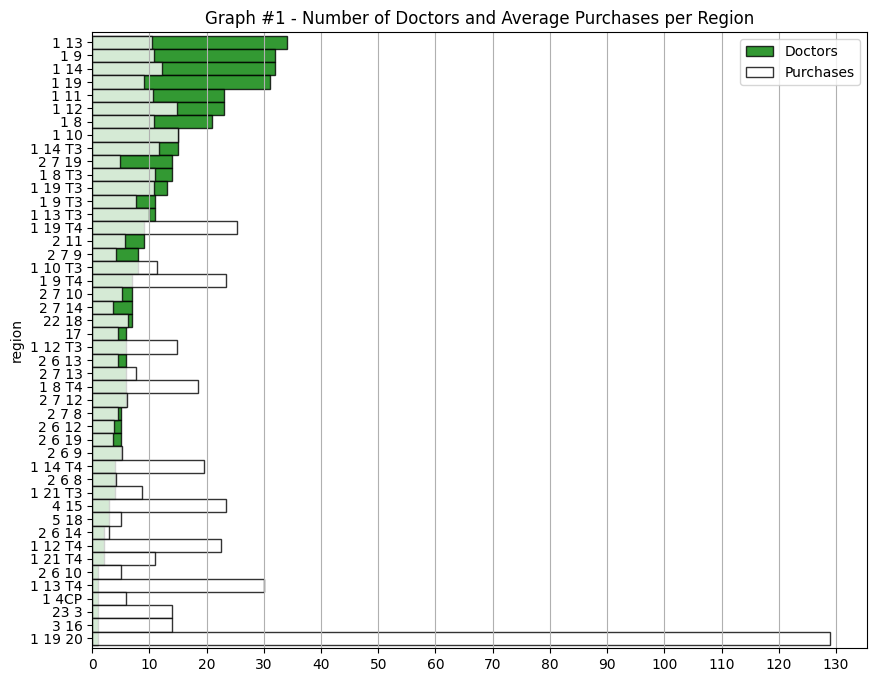

In [ ]:
#Obtaining number of doctors and average purchases per region, ordered by doctors
purchase_per_region = doctors.groupby("Region")["Purchases"].mean()
dr_per_region = doctors.Region.value_counts().sort_index()
dr_per_region = dr_per_region.reset_index(drop = False).reset_index()
dr_per_region["avg_purchases"] = purchase_per_region.values
dr_per_region.rename({"Region": "#dr",
                      "index": "region"}, axis = 1, inplace = True)
dr_per_region = dr_per_region.sort_values("#dr", ascending = False).drop("level_0", axis = 1).set_index("region")

dr = dr_per_region["#dr"]
pur = dr_per_region["avg_purchases"]

#Plotting findings
plt.figure(figsize = (10, 8))
dr.plot(kind = "barh", width= 1 , color = "green", edgecolor = "black", alpha = 0.8, label = "Doctors")
pur.plot(kind = "barh", width= 1, color = "white", edgecolor = "black", alpha = 0.8, label = "Purchases")
plt.gca().invert_yaxis()
plt.xticks(range(0, 131, 10))
plt.grid(True, axis = "x")
plt.title("Graph #1 - Number of Doctors and Average Purchases per Region")
plt.legend()
plt.show()

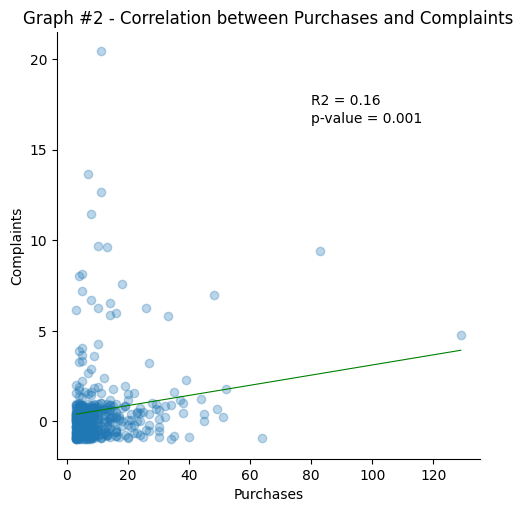

In [ ]:
#Obtaining number of complaints per Doctor
complaints_per_doctor = complaints.groupby("DoctorID", as_index = False)["Qty"]\
                                    .sum()\
                                    .sort_values("Qty", ascending = False)

#Merging findings with the "doctors" data set
doctors_complaints_merged = doctors.merge(complaints_per_doctor, on = "DoctorID", how = "left", validate = "one_to_one")

#Filling missing values with 0, meaning no complaints were made
doctors_complaints_merged.Qty.fillna(0, inplace = True)

#Checking for relationship between purchases and complaints
y = doctors_complaints_merged.Qty
x = doctors_complaints_merged.Purchases
statistic, pvalue = stats.pearsonr(x, y)

#Plotting findings
sns.lmplot(x = "Purchases", y = "Qty", data = doctors_complaints_merged, ci = None,\
           y_jitter = True, scatter_kws = {"alpha" : 0.3},\
           line_kws = {"color" : "g",
                    "linewidth" : 0.8})
plt.title("Graph #2 - Correlation between Purchases and Complaints")
plt.annotate(f"R2 = {round(statistic, 2)}", (80.0, 17.5))
plt.annotate(f"p-value = {round(pvalue, 4)}", (80.0, 16.5))
plt.ylabel("Complaints")
plt.show()

In [ ]:
#Filling two Rank missing values with median
mode = doctors_complaints_merged["Rank"].mode()[0]
doctors_complaints_merged["Rank"].fillna(mode, inplace = True)

#Changing Rank ordinal variable to numeric
doctors_complaints_merged["Rank"] = doctors_complaints_merged.Rank.map({"Silver": 0,
                               "Silver Plus": 1,
                               "Gold": 2,
                               "Gold Plus": 3,
                               "Platinum": 4,
                               "Platinum Plus": 5,
                               "Titanium": 6,
                               "Titanium Plus": 7,
                               "Ambassador": 8})
doctors_complaints_merged["Rank"] = doctors_complaints_merged.Rank.astype("float")

#Filling Satisfaction missing values
median = doctors_complaints_merged.Satisfaction[doctors_complaints_merged.Satisfaction != "--"].median()
doctors_complaints_merged.Satisfaction.replace({"--" : median}, inplace = True)
doctors_complaints_merged["Satisfaction"] = doctors_complaints_merged.Satisfaction.astype("float")

NameError: name 'doctors_complaints_merged' is not defined

In [ ]:
#Removing outliers for more accuracy
columns = ["Rank", "Incidence rate", "R rate", "Satisfaction", "Experience", "Purchases", "Qty"]

doctors_complaints_merged = doctors_complaints_merged\
[(np.abs(stats.zscore(doctors_complaints_merged[columns])) < 3).all(axis=1)]

In [ ]:
#Leaving only numeric variables for ML tasks
samples = doctors_complaints_merged.drop(["DoctorID", "Region", "Category"], axis = 1)

In [ ]:
#Performing Standardization
from sklearn.preprocessing import StandardScaler
scaled_samples = StandardScaler().fit_transform(samples)

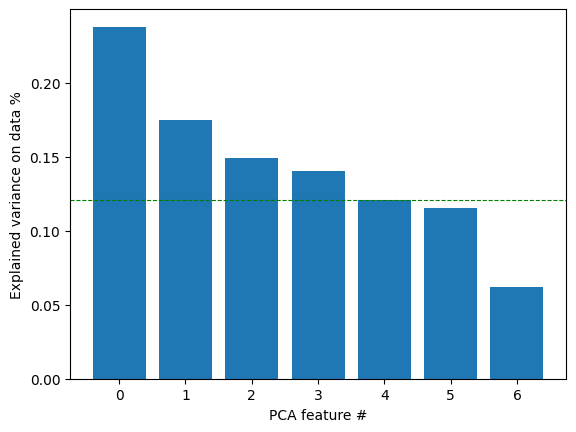

5 PCA features cumulatively explain 82.3% of the data.


In [ ]:
#Performing Principal Component Analysis
from sklearn.decomposition import PCA
pca = PCA().fit(scaled_samples)

#Check how many relevant components there are
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_)
plt.xticks(features)
plt.xlabel("PCA feature #")
plt.ylabel("Explained variance on data %")

#Drawing a line where values above make more than 80% of the data
plt.axhline(pca.explained_variance_ratio_[np.cumsum(pca.explained_variance_ratio_) >= 0.8][0]\
            , color = "g", lw = 0.8, ls = "--")
plt.show()

print(f"5 PCA features cumulatively explain {round(sum(pca.explained_variance_ratio_[:5]), 3)*100}% of the data.")

In [ ]:
#Reduce the dimensionality of the data
pca2 = PCA(n_components = 5).fit(scaled_samples)
samples_reduced = pca2.transform(scaled_samples)

In [ ]:
pca2_df = pd.DataFrame(abs(pca2.components_), columns= samples.columns, index = ["PC_1", "PC_2", "PC_3", "PC_4", "PC_5"])
pca2_df[pca2_df >= 0.5]

,Rank,Incidence rate,R rate,Satisfaction,Experience,Purchases,Qty
PC_1,0.657943,NaN,NaN,NaN,NaN,0.649513,NaN
PC_2,NaN,NaN,0.620062,NaN,0.618236,NaN,NaN
PC_3,NaN,NaN,NaN,0.645004,NaN,NaN,0.680176
PC_4,NaN,0.659833,NaN,0.576653,NaN,NaN,NaN
PC_5,NaN,NaN,NaN,NaN,0.567034,NaN,NaN


In [ ]:
print("Using a threshold of 0.5, the most important values of the Principal Components are:", "\n\n", "Component_1: Purchases + Rank", "\n", "Component_2: R rate + Experience", "\n", "Component_3: Satisfaction + Complaints", "\n", "Component_4: Satisfaction + Complaints", "\n", "Component_5: R rate + Experience")

Using a threshold of 0.5, the most important values of the Principal Components are: 

 Component_1: Purchases + Rank 
 Component_2: R rate + Experience 
 Component_3: Satisfaction + Complaints 
 Component_4: Satisfaction + Complaints 
 Component_5: R rate + Experience


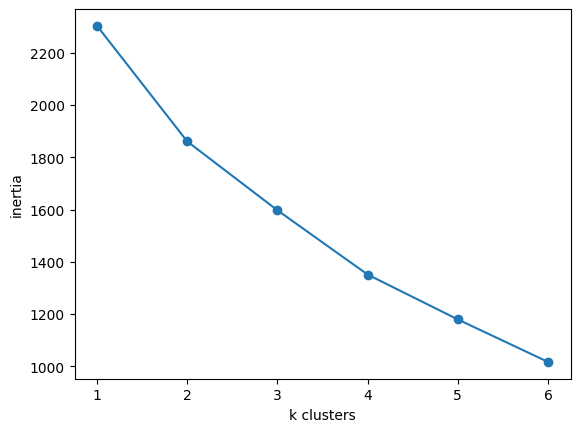

In [ ]:
#Performing "elbow" method to understand how many clusters to divide the data into
from sklearn.cluster import KMeans
inertia_values = []
for k in range(1, 7):
    KM = KMeans(n_clusters = k).fit(samples_reduced)
    inertia_values.append(KM.inertia_)
plt.plot(range(1, 7), inertia_values, marker = "o")
plt.xlabel("k clusters")
plt.ylabel("inertia")
plt.show()

In [ ]:
#Fitting a KMeans model with optimal clusters
KM2 = KMeans(n_clusters = 4, random_state= 9).fit(samples_reduced)
labels = KM2.predict(samples_reduced)

In [ ]:
#Adding a new feature - Complaints to Purchase Ratio
doctors_complaints_merged["complaints_to_purchaces_ratio"] = doctors_complaints_merged["Qty"]/ doctors_complaints_merged["Purchases"]

#Adding the labels to the data set
doctors_complaints_merged["persona"] = labels

print("Table #1 - Personas average values for each variable")
display(doctors_complaints_merged.groupby(labels).mean())
print(doctors_complaints_merged.persona.value_counts(normalize = True))

Table #1 - Personas average values for each variable


,Rank,Incidence rate,R rate,Satisfaction,Experience,Purchases,Qty,complaints_to_purchaces_ratio,persona
0,6.052632,3.926316,1.128947,12.707895,0.576316,14.210526,3.894737,0.534837,0.0
1,7.075000,5.757167,0.988667,45.203667,0.341083,16.866667,0.141667,0.010464,1.0
2,3.195122,4.232134,0.746524,22.941707,0.294634,5.536585,0.103659,0.021308,2.0
3,4.783505,4.139278,1.652680,38.149278,0.938660,6.865979,0.092784,0.017714,3.0


2    0.4100
1    0.3000
3    0.2425
0    0.0475
Name: persona, dtype: float64


In [ ]:
#Filtering doctors that fit personas
doctors_complaints_merged["persona"] = doctors_complaints_merged["persona"].astype("object")
doctors_complaints_merged["persona"] = doctors_complaints_merged.persona.map({0 : "Millennial",
                                                                              1 : "Fan",
                                                                              2 : "Bootstrapper",
                                                                              3 : "Conservative"})

dr_persona = doctors_complaints_merged[["DoctorID", "persona"]]

In [ ]:
#Investigating trained labels in orders made for patterns
All = doctors.merge(complaints_per_doctor, on = "DoctorID", how = "left", validate = "one_to_one")\
                .merge(instructions, on = "DoctorID", how = "left", validate = "one_to_one")\
                .merge(orders, on = "DoctorID", how = "left", validate = "one_to_many")\
                .merge(dr_persona, on = "DoctorID", how = "right", validate = "many_to_one")

All_conditions = All[All["Condition C"].notna()]
All_conditions["Condition J"] = All_conditions["Condition J"].fillna("Before")
All_conditions["Instructions"] = All_conditions["Instructions"].fillna("No")
All_conditions.replace({True : 1,
                        False : 0,
                        "Before" : 0,
                        "After" : 1,
                        "--" : 0}, inplace = True)
display(All_conditions.groupby("persona").mean())
print("There is no evident patterns in the Conditions of the orders, that would justify a high level of complaints")

,Incidence rate,R rate,Experience,Purchases,Qty,Condition A,Condition B,Condition C,Condition D,Condition F,Condition G,Condition H,Condition I,Condition J
persona,,,,,,,,,,,,,,
Bootstrapper,4.662500,0.801000,0.180000,5.450000,1.450000,0.125000,0.125000,0.100000,0.150000,0.000000,0.200000,0.200000,0.050000,0.025000
Conservative,3.411333,1.870667,0.751333,6.600000,1.066667,0.066667,0.066667,0.000000,0.066667,0.000000,0.200000,0.333333,0.066667,0.000000
Fan,5.556721,1.040492,0.507213,20.311475,1.131148,0.180328,0.131148,0.081967,0.131148,0.016393,0.131148,0.262295,0.049180,0.000000
Millennial,3.673333,0.983500,0.695833,18.966667,3.416667,0.050000,0.100000,0.216667,0.166667,0.000000,0.200000,0.383333,0.050000,0.016667


There is no evident patterns in the Conditions of the orders, that would justify a high level of complaints


In [ ]:
#Quantity of complaints and their type within known labels
complaints_personas = dr_persona.merge(complaints, on = "DoctorID", how = "left", validate = "one_to_many")
complaints_personas.groupby(["persona", "Complaint Type"])["Qty"].count()

persona       Complaint Type
Bootstrapper  Correct            6
              Incorrect          6
              Unknown            5
Conservative  Correct            3
              Incorrect          2
              Specific           1
              Unknown            2
Fan           Correct            9
              Incorrect          3
              Unknown            3
Millennial    Correct           19
              Incorrect          9
              Specific           1
              Unknown           11
Name: Qty, dtype: int64

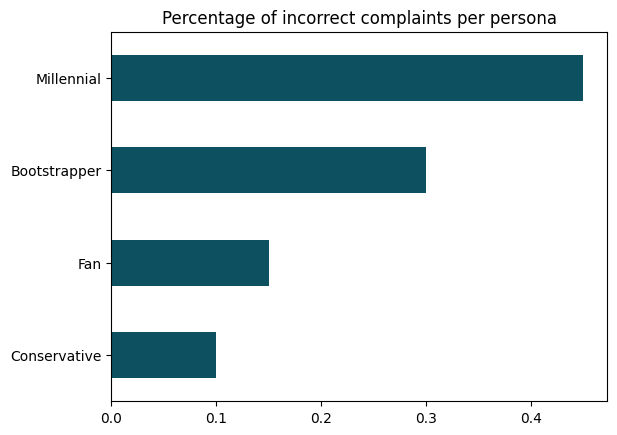

In [ ]:
#Percentage of incorrect complaints per persona
complaints_personas_filtered = complaints_personas[complaints_personas["Complaint Type"] == "Incorrect"]
complaints_personas_filtered.persona.value_counts(normalize = True).sort_values().plot(kind = "barh", color = "#0d5060")
plt.title("Percentage of incorrect complaints per persona")
plt.show()

In [ ]:
#Top 10
display(All.sort_values("Qty", ascending = False).head(10))
print("The top 10 complaint placers, the Doctor ID 'FAICB' had placed an unusual amount of complaints, 6 per order")

,DoctorID,Region,Category,Rank,Incidence rate,R rate,Satisfaction,Experience,Purchases,Qty,Instructions,OrderID,OrderNum,Condition A,Condition B,Condition C,Condition D,Condition F,Condition G,Condition H,Condition I,Condition J,persona
383,ABHGCJ,2 7 8,Specialist,Gold,3.00,1.00,100.00,0.00,3.0,6.0,NaN,DGDGGFH,AFFADGA,False,False,False,False,False,False,False,False,NaN,Millennial
37,ABJEAI,1 19,Specialist,Ambassador,9.00,0.90,-100.00,0.70,10.0,6.0,NaN,DGEJFDC,AIBEHCJ,False,False,False,False,False,True,True,False,Before,Millennial
204,FAICB,1 19,Specialist,Ambassador,4.50,0.97,--,0.76,33.0,6.0,NaN,DFIAGCC,AFCCIBI,False,False,False,False,False,False,False,False,NaN,Millennial
205,FAICB,1 19,Specialist,Ambassador,4.50,0.97,--,0.76,33.0,6.0,NaN,DGAGBIC,AGJCEBJ,False,False,False,False,False,False,False,False,NaN,Millennial
206,FAICB,1 19,Specialist,Ambassador,4.50,0.97,--,0.76,33.0,6.0,NaN,DGFEGAJ,AGHDCCC,False,False,NaN,False,NaN,NaN,False,False,NaN,Millennial
207,FAICB,1 19,Specialist,Ambassador,4.50,0.97,--,0.76,33.0,6.0,NaN,DGHAHAD,AICGICG,False,True,False,False,False,False,False,False,Before,Millennial
208,FAICB,1 19,Specialist,Ambassador,4.50,0.97,--,0.76,33.0,6.0,NaN,DGIEGIA,AIDCGDJ,True,True,False,False,False,False,True,False,Before,Millennial
384,ABHGCJ,2 7 8,Specialist,Gold,3.00,1.00,100.00,0.00,3.0,6.0,NaN,DGGHEDF,AICFEJH,False,False,False,False,False,False,False,False,Before,Millennial
293,FBJIB,1 14,Specialist,Platinum Plus,3.67,1.14,-33.33,0.93,14.0,6.0,NaN,DGAGBII,AIABGAJ,False,False,False,False,False,False,False,False,Before,Millennial
292,FAGBJ,3 16,Specialist,Ambassador,3.67,0.21,--,1.07,14.0,6.0,NaN,DGFDCFI,AICJGFB,False,False,False,False,False,False,True,False,Before,Millennial


The top 10 complaint placers, the Doctor ID 'FAICB' had placed an unusual amount of complaints, 6 per order


### Code of ML pipeline for repeatability

In [ ]:
def miguel_approach (data):
    '''ML pipeline for k-means clustering of Johansson & Johansson's customer segments
 
 Args:
    data (Pandas DataFrame): Data frame containing only numerical (continuous and ordinal) data
    
Returns:
    Does not return
    
Raises:
    TypeError: The selected argument must be a Pandas DataFrame/ 2D array
    ValueError: The selected argumnet contains data that is not numerical (continuous or ordinal)
    '''
    if isinstance(data, pd.DataFrame): 
        from sklearn.preprocessing import StandardScaler
        from sklearn.decomposition import PCA
        from sklearn.cluster import KMeans
        from sklearn.pipeline import make_pipeline
        scaler = StandardScaler()
        pca = PCA(n_components= 5, random_state= 9)
        k_means = KMeans(n_clusters = 4, random_state= 9)
        pipeline = make_pipeline(scaler, pca, k_means)
        pipeline.fit(data)
        labels = pipeline.predict(data)
    else:
        raise TypeError("argument has to be a pandas DataFrame/ 2D array with numerical (continuous or ordinal) features.")